In [ ]:
import pandas as pd
import os
import librosa 
import numpy as np


# mehrklassen probieren
# loss funktion recherchieren
# verschiedene Window Größen

WINDOW_LENGTH = 30

data = "./features-relative.csv"
signals_folder = "./Spontanaktivität"
signals = {}

for file in os.listdir(signals_folder):
    file_path = os.path.join(signals_folder, file)
    signal, fs = librosa.load(file_path)
    signals[file] = signal

df = pd.read_csv(data)

labels = {}

for index, row in df.iterrows():
    if str(row["Label"]).lower() in ["fibrillation", "psw"]:
        key = row["file"] 
        item = {"label": row["Label"], "start": row["Start"], "end": row["End"]}

        if key not in labels:
            labels[key] = []

        labels[key].append(item)


c:\Users\joaqu\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\joaqu\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\joaqu\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


In [2]:
training_df = pd.DataFrame(columns=["file", "segment", "signal", "labels"])

def slice_signal(signal, fs, window_seconds):
    window_len = int(window_seconds * fs)
    slices = []

    for start in range(0, len(signal), window_len):
        end = start + window_len
        chunk = signal[start:end]

        if len(chunk) < window_len:
            padding = window_len - len(chunk)
            chunk = np.pad(chunk, (0, padding))
        
        slices.append(chunk)

    return slices

def generate_sample_labels(annotations, window_start, window_end, fs):
    window_length = int((window_end - window_start) * fs)
    labels_array = np.zeros(window_length, dtype=np.int32)

    for ann in annotations:
        event_start = ann["start"]
        event_end = ann["end"]

        if event_end <= window_start or event_start >= window_end:
            continue 

        start_idx = int(max(event_start - window_start, 0) * fs)
        end_idx = int(min(event_end - window_start, window_end - window_start) * fs)

        labels_array[start_idx:end_idx] = 1
    
    return labels_array

for file in labels.keys():
    filename = os.path.basename(file)
    signal = signals[filename]
    slices = slice_signal(signal, fs, WINDOW_LENGTH)
    index = 0
    for slice in slices:
        index += 1
        try:
            window_start = index * WINDOW_LENGTH
            window_end = window_start + WINDOW_LENGTH
            segment_labels = generate_sample_labels(labels[file], window_start, window_end, fs)
            print(segment_labels)

            training_df.loc[len(training_df)] = {
            "file": file,
            "segment": index,
            "signal": slice,
            "labels": segment_labels
            }
        except Exception as e:
            print(f"Error: {e}")
            pass


[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]


In [3]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, BatchNormalization, Flatten, Dense
from tensorflow.keras.models import Sequential

x = training_df["signal"].tolist()
y = training_df["labels"].tolist()

x = np.array(x)  # Shape: (num_samples, 220500)
x = x.reshape(-1, WINDOW_LENGTH * fs, 1)  # Shape: (num_samples, 220500, 1)
y = np.array(y)  # Shape: (num_samples,)


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)

model = Sequential([
    Conv1D(64, 7, activation='relu', padding='same', input_shape=(WINDOW_LENGTH*fs,1)),
    BatchNormalization(),
    Conv1D(128, 5, activation='relu', padding='same'),
    BatchNormalization(),
    # optionally more conv layers, but avoid pooling (or add UpSampling1D later)
    Conv1D(1, 1, activation='sigmoid', padding='same')
])


c:\Users\joaqu\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

monitor = EarlyStopping(monitor='val_loss',
                        mode='min', 
                        restore_best_weights=True,
                        patience=5)

In [ ]:
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
X_train, y_train = shuffle(x_train, y_train, random_state=42)


history = model.fit(X_train, y_train,
                    epochs=100,
                    validation_split=0.1,
                    callbacks=[monitor],)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 343s 343s/step - accuracy: 0.8715 - loss: 0.7432 - val_accuracy: 1.0000 - val_loss: 0.6854
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 197s 197s/step - accuracy: 0.1442 - loss: 0.7166 - val_accuracy: 1.0000 - val_loss: 0.6777
Epoch 3/100


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Classification Report:


ValueError: Classification metrics can't handle a mix of multilabel-indicator and multiclass targets

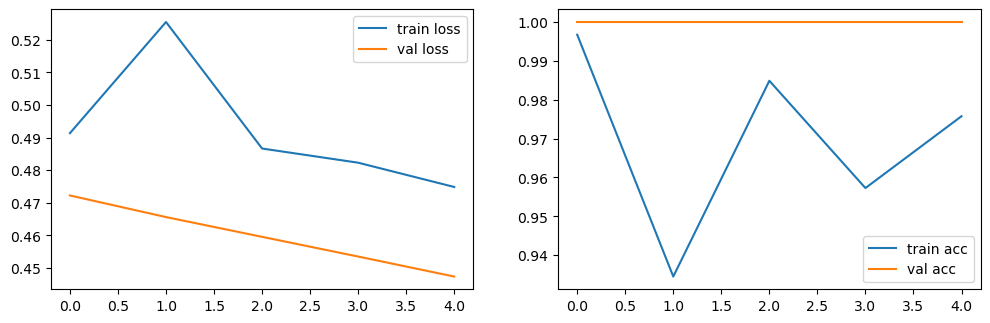

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()

y_pred = model.predict(X_train)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:")
print(classification_report(y_train, y_pred_classes, target_names=['Class 0', 'Class 1']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_train, y_pred_classes))
# with badnpass, 7 87 accuracy
# bandpass, 3 91

In [ ]:
training_df.to_csv("s2s.csv")

In [ ]:
training_df["labels"].head

<bound method NDFrame.head of 0     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
1     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
5     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
6     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
7     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
8     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
9     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
10    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
11    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
12    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
13    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
14    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
15    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
16    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
17    [1, 1, 1, 1,